# Práctica 3 - Exploración de un dataset con pandas

## Objetivos

En esta práctica trabajarás con un dataset de clientes utilizando Python.

Al finalizar deberás ser capaz de:

- cargar datos desde un archivo CSV
- trabajar con un `DataFrame` de pandas
- identificar muestras y variables
- consultar la estructura de un dataset
- calcular estadísticas descriptivas
- seleccionar y filtrar datos
- analizar variables categóricas
- crear visualizaciones sencillas
- identificar las características \(X\) y la variable objetivo \(y\)
- determinar qué tipo de problema de Machine Learning podría resolverse

> **Importante:** no debes entrenar ningún modelo de Machine Learning en esta práctica.

## Contexto

Una empresa de telecomunicaciones quiere analizar el comportamiento de sus clientes. Dispone de información histórica y conoce qué clientes terminaron abandonando el servicio.

El objetivo futuro será desarrollar un sistema capaz de predecir:

> **¿Qué clientes tienen riesgo de abandonar la compañía?**

Para realizar la práctica utilizaremos el archivo `clientes.csv`.

| Variable | Descripción |
|---|---|
| `cliente_id` | Identificador del cliente |
| `edad` | Edad del cliente |
| `antiguedad` | Meses como cliente |
| `cuota_mensual` | Cuota mensual en euros |
| `consumo_datos` | Consumo mensual de datos en GB |
| `llamadas_soporte` | Número de llamadas a soporte |
| `incidencias` | Número de incidencias registradas |
| `tipo_contrato` | Mensual, anual o bienal |
| `satisfaccion` | Valoración del servicio de 1 a 5 |
| `abandono` | Indica si el cliente abandonó: Sí/No |

Cada fila corresponde a un cliente.

### Instrucciones

Completa las celdas de código marcadas con `# TODO`.

Cuando se solicite una interpretación, escribe tu respuesta en la celda Markdown correspondiente. No basta con ejecutar código: debes **interpretar los resultados**.

## Parte 1 - Preparación del entorno

### Ejercicio 1 - Importación

Importa NumPy, pandas y Matplotlib utilizando los alias convencionales.

In [29]:
# TODO: importa NumPy, pandas y matplotlib.pyplot
import numpy as np #Arrays, operaciones y numeros
import pandas as pd #Dataframe-> Tablas
import matplotlib.pyplot as plt #Representación gráfica de los datos

### Respuesta

Explica brevemente para qué utilizaremos cada biblioteca:

- **NumPy:** 
- **pandas:** 
- **Matplotlib:**

## Parte 2 - Carga e inspección inicial

### Ejercicio 2 - Cargar el dataset

Carga `clientes.csv` en un DataFrame denominado `df` y muestra sus primeras filas.

In [30]:
# TODO: carga el archivo clientes.csv en df
df = pd.read_csv('clientes.csv')
# TODO: muestra las primeras filas
df.head()

,cliente_id,edad,antiguedad,cuota_mensual,consumo_datos,llamadas_soporte,incidencias,tipo_contrato,satisfaccion,abandono
0,10001,23,61.0,32.16,11.9,1,2,Mensual,1,No
1,10002,62,79.0,45.71,17.4,2,0,Anual,2,No
2,10003,55,49.0,60.48,14.6,0,1,Mensual,5,No
3,10004,43,6.0,116.82,21.8,4,0,Anual,3,No
4,10005,43,70.0,36.13,8.8,2,2,Anual,1,Sí


### Respuesta

**¿Qué representa cada fila del DataFrame?**

Escribe aquí tu respuesta.

**¿Qué representa cada columna?**

Escribe aquí tu respuesta.

### Ejercicio 3 - Dimensiones

Obtén mediante código las dimensiones del dataset.

In [31]:
# TODO: muestra las dimensiones del DataFrame
df.shape

(180, 10)

### Respuesta

- **Número de muestras:** 
- **Número de variables:**

### Ejercicio 4 - Columnas

Obtén mediante código los nombres de todas las columnas.

In [32]:
# TODO: muestra los nombres de las columnas
df.columns

Index(['cliente_id', 'edad', 'antiguedad', 'cuota_mensual', 'consumo_datos',
       'llamadas_soporte', 'incidencias', 'tipo_contrato', 'satisfaccion',
       'abandono'],
      dtype='str')

### Respuesta

**¿Qué columna parece representar la variable que queremos predecir? ¿Por qué?**

Escribe aquí tu respuesta.

### Ejercicio 5 - Tipos de datos

Obtén los tipos de datos de todas las columnas.

In [33]:
# TODO: consulta los tipos de datos
df.dtypes

cliente_id            int64
edad                  int64
antiguedad          float64
cuota_mensual       float64
consumo_datos       float64
llamadas_soporte      int64
incidencias           int64
tipo_contrato           str
satisfaccion          int64
abandono                str
dtype: object

### Respuesta

**Variables numéricas:**

Las variables que admiten número y se usan en operaciones.

**Variables categóricas:**

El resto de variables que no son numéricas

**¿`cliente_id` debería considerarse una característica numérica simplemente porque contiene números? Razona la respuesta.**
No, porque aunque sean números no se opera con ellos por lo que es categorica
Escribe aquí tu respuesta.

## Parte 3 - Estructura y calidad inicial

### Ejercicio 6 - Información general

Utiliza `info()` para analizar la estructura del dataset.

In [34]:
# TODO: muestra la información general del DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cliente_id        180 non-null    int64  
 1   edad              180 non-null    int64  
 2   antiguedad        178 non-null    float64
 3   cuota_mensual     180 non-null    float64
 4   consumo_datos     179 non-null    float64
 5   llamadas_soporte  180 non-null    int64  
 6   incidencias       180 non-null    int64  
 7   tipo_contrato     180 non-null    str    
 8   satisfaccion      180 non-null    int64  
 9   abandono          180 non-null    str    
dtypes: float64(3), int64(5), str(2)
memory usage: 14.2 KB


### Respuesta

- ¿Cuántas entradas contiene?
- 180
- ¿Qué tipos de datos aparecen?
- float64(3), int64(5), str(2)
- ¿Todas las columnas contienen el mismo número de valores no nulos?
- No
- ¿Parece existir algún valor ausente?
- Si
- ¿Cómo puedes deducirlo a partir de `info()`?
- Cuando en una columna hay menos valores que en el resto, quiere decir que en esa columna en algún registro falta el dato

Escribe aquí tu análisis.

## Parte 4 - Estadística descriptiva

### Ejercicio 7 - Descripción estadística

Obtén las estadísticas descriptivas de las variables numéricas.

In [35]:
# TODO: genera las estadísticas descriptivas
df.describe()

,cliente_id,edad,antiguedad,cuota_mensual,consumo_datos,llamadas_soporte,incidencias,satisfaccion
count,180.000000,180.000000,178.000000,180.000000,179.000000,180.000000,180.000000,180.000000
mean,10090.500000,47.283333,62.050562,71.185667,16.408380,1.705556,1.111111,3.016667
std,52.105662,15.929059,33.991071,29.279251,9.813719,1.249345,1.082563,1.423957
min,10001.000000,18.000000,1.000000,20.480000,1.200000,0.000000,0.000000,1.000000
25%,10045.750000,34.000000,34.000000,43.172500,9.800000,1.000000,0.000000,2.000000
50%,10090.500000,47.000000,61.000000,72.690000,14.300000,1.000000,1.000000,3.000000
75%,10135.250000,62.000000,91.750000,97.177500,20.400000,2.250000,2.000000,4.000000
max,10180.000000,75.000000,120.000000,119.440000,54.200000,6.000000,5.000000,5.000000


### Interpretación

A partir del resultado, indica:

- edad media;
- 47.283333
- edad mínima;
- 18
- edad máxima;
- 75
- cuota mensual media;
- 71.185667
- cuota mensual máxima;
- 119.44
- media de llamadas a soporte;
- 1.705556
- media de incidencias;
- 1.111111
- satisfacción media.
- 3.016667

Escribe aquí una breve interpretación, no solo los valores.
mean es la media, min el minimo y max el máximo

### Ejercicio 8 - Cálculos individuales

Calcula mediante instrucciones independientes los valores solicitados.

In [36]:
# TODO: media de edad
print(f"Media: {df['edad'].mean():.3f}")
#print(f"Media: {df['edad'].mean()}")
#print(df['edad'].mean())

# TODO: mediana de edad
print(f"Mediana: {df['edad'].median()}")

# TODO: cuota mínima
print(f"Cuota Mínima: {df['cuota_mensual'].min()}")

# TODO: cuota máxima
print(f"Couta Máxima: {df['cuota_mensual'].max()}")

# TODO: número total de incidencias
print(f"Incidencias totales: {df['incidencias'].sum()}")

# TODO: satisfacción media
print(f"Satisfaccion media: {df['satisfaccion'].mean()}")

Media: 47.283
Mediana: 47.0
Cuota Mínima: 20.48
Couta Máxima: 119.44
Incidencias totales: 200
Satisfaccion media: 3.0166666666666666


### Comprobación

¿Coinciden estos resultados con los obtenidos mediante `describe()` cuando corresponde?

Escribe aquí tu respuesta.

SI

## Parte 5 - Selección de información

### Ejercicio 9 - Selección de columnas

Crea un DataFrame `df_clientes` que contenga únicamente `edad`, `antiguedad`, `cuota_mensual`, `satisfaccion` y `abandono`. Muestra sus primeras cinco filas.

In [37]:
# TODO: crea df_clientes
filtro = ['edad', 'antiguedad', 'cuota_mensual', 'satisfaccion','abandono']
df_clientes = df[filtro]
#En el de abajo al tener que pasarle una lista dado que no hemos creado un filtro previo, necesitamos abrir los corchetes de el df y los corchetes de creacion de la lista
#df_clientes = df[['edad', 'antiguedad', 'cuota_mensual', 'satisfaccion','abandono']]
df_clientes.head()
# TODO: muestra las primeras cinco filas

,edad,antiguedad,cuota_mensual,satisfaccion,abandono
0,23,61.0,32.16,1,No
1,62,79.0,45.71,2,No
2,55,49.0,60.48,5,No
3,43,6.0,116.82,3,No
4,43,70.0,36.13,1,Sí


### Respuesta

**¿Sigue representando cada fila al mismo cliente que en el DataFrame original? Explica por qué.**

Escribe aquí tu respuesta.
Si, simplemente hemos escogido que columnas queremos.

## Parte 6 - Filtrado

### Ejercicio 10 - Clientes por edad

Obtén todos los clientes mayores de 50 años y calcula cuántos cumplen la condición.

In [38]:
# TODO: filtra los clientes mayores de 50 años
#Devuelve true o false dependiendo de si son mayores o no de 50
"""
result = df['edad'] > 50
print(result)
"""
#Al pasarselo a df te devuelve solo los que tienen true por lo que te devuelve los que son mayores de 50 años
#mayores_50 = df[df['edad']> 50]
filtro = df['edad']> 50
mayores_50 = df[filtro]
print(mayores_50)
# TODO: calcula cuántos son
print("Cantidad de mayores de 50: ", len(mayores_50))

     cliente_id  edad  antiguedad  cuota_mensual  consumo_datos  \
1         10002    62        79.0          45.71           17.4   
2         10003    55        49.0          60.48           14.6   
5         10006    67         3.0         105.63           15.8   
7         10008    58       101.0          53.70            8.1   
11        10012    74        27.0          61.04            5.2   
..          ...   ...         ...            ...            ...   
172       10173    62        96.0          35.35           38.5   
173       10174    59        65.0         104.90           26.7   
174       10175    58        66.0          95.67           22.6   
176       10177    59       119.0          74.58           11.2   
178       10179    70        61.0          94.18           43.3   

     llamadas_soporte  incidencias tipo_contrato  satisfaccion abandono  
1                   2            0         Anual             2       No  
2                   0            1       Mensua

### Ejercicio 11 - Clientes con incidencias

Selecciona los clientes que tengan `incidencias > 0` y determina cuántos son.

In [39]:
# TODO: filtra los clientes con incidencias
filtro = df['incidencias']>0
df_incidencias = df[filtro]
print(df_incidencias)

# TODO: calcula cuántos son
print("Cantidad de clientes con incidencias: ",len(df_incidencias))

     cliente_id  edad  antiguedad  cuota_mensual  consumo_datos  \
0         10001    23        61.0          32.16           11.9   
2         10003    55        49.0          60.48           14.6   
4         10005    43        70.0          36.13            8.8   
5         10006    67         3.0         105.63           15.8   
6         10007    22        34.0          36.20           10.2   
..          ...   ...         ...            ...            ...   
169       10170    19       100.0          73.09            8.0   
173       10174    59        65.0         104.90           26.7   
174       10175    58        66.0          95.67           22.6   
175       10176    44        84.0         117.48           53.3   
178       10179    70        61.0          94.18           43.3   

     llamadas_soporte  incidencias tipo_contrato  satisfaccion abandono  
0                   1            2       Mensual             1       No  
2                   0            1       Mensua

### Ejercicio 12 - Condiciones combinadas

Obtén los clientes que cumplan simultáneamente:

\[
edad < 30
\]

y

\[
llamadas\_soporte \geq 3
\]

Muestra únicamente `cliente_id`, `edad`, `llamadas_soporte` y `abandono`.

In [40]:
# TODO: realiza el filtro y muestra únicamente las columnas solicitadas
filtro = (df['edad']<30) & (df['llamadas_soporte']>=3)
df_filtrado = df[filtro]
columnas = ['cliente_id','edad', 'llamadas_soporte','abandono']
print(df_filtrado[columnas])

     cliente_id  edad  llamadas_soporte abandono
17        10018    25                 3       No
22        10023    28                 3       No
35        10036    21                 3       Sí
55        10056    20                 3       No
101       10102    29                 3       No
117       10118    26                 3       Sí
119       10120    24                 3       No
132       10133    23                 4       No
146       10147    20                 3       No
167       10168    27                 6       Sí
169       10170    19                 3       Sí


### Respuesta

**¿Qué operador has utilizado para combinar ambas condiciones?**

Escribe aquí tu respuesta.

### Ejercicio 13 - Segundo filtro combinado

Localiza clientes que cumplan:

\[
satisfaccion \leq 2
\]

y

\[
incidencias \geq 2
\]

Muestra las filas encontradas.

In [41]:
# TODO: realiza el filtro
filtro = (df['satisfaccion']<=2) & (df['incidencias']>=2)
df_filtrado = df[filtro]
columnas = ['cliente_id','satisfaccion', 'incidencias','abandono']
print(df_filtrado[columnas])

     cliente_id  satisfaccion  incidencias abandono
0         10001             1            2       No
4         10005             1            2       Sí
5         10006             2            2       No
11        10012             1            5       Sí
19        10020             1            2       No
20        10021             2            2       Sí
24        10025             1            2       Sí
25        10026             2            2       Sí
35        10036             1            2       Sí
44        10045             1            2       No
46        10047             2            4       Sí
50        10051             2            2       No
59        10060             2            3       Sí
61        10062             1            2       No
62        10063             2            4       Sí
65        10066             1            2       Sí
67        10068             1            3       Sí
89        10090             2            2       Sí
104       10

### Reflexión

**Observando únicamente estos resultados, ¿podemos afirmar que una satisfacción baja provoca el abandono?**

Justifica tu respuesta.

## Parte 7 - Variables categóricas

### Ejercicio 14 - Tipo de contrato

Obtén los diferentes valores de `tipo_contrato` y calcula cuántos clientes pertenecen a cada categoría.

In [42]:
# TODO: muestra las categorías existentes
print(df['tipo_contrato'].unique())

# TODO: calcula la frecuencia de cada categoría
print("Frecuencia: ", df['tipo_contrato'].value_counts())

<StringArray>
['Mensual', 'Anual', 'Bienal']
Length: 3, dtype: str
Frecuencia:  tipo_contrato
Mensual    94
Anual      56
Bienal     30
Name: count, dtype: int64


### Respuesta

**¿Cuál es el tipo de contrato más frecuente?**

Escribe aquí tu respuesta.

### Ejercicio 15 - Variable `abandono`

Obtén las categorías existentes, el número de clientes de cada categoría y sus frecuencias relativas.

In [43]:
# TODO: categorías existentes
print("Categorias: ",df['abandono'].unique())

# TODO: frecuencias absolutas
print("Frecuencia: ", df['abandono'].value_counts())

# TODO: frecuencias relativas
print("Frecuencia: ", df['abandono'].value_counts(normalize=True))

Categorias:  <StringArray>
['No', 'Sí']
Length: 2, dtype: str
Frecuencia:  abandono
No    110
Sí     70
Name: count, dtype: int64
Frecuencia:  abandono
No    0.611111
Sí    0.388889
Name: proportion, dtype: float64


### Interpretación

Expresa las frecuencias relativas mediante porcentajes y redacta una breve conclusión sobre la distribución de `abandono`.

Escribe aquí tu respuesta.

## Parte 8 - Visualización

Todos los gráficos deben contener como mínimo:

- título;
- etiquetas de los ejes cuando correspondan;
- una representación clara.

### Ejercicio 16 - Distribución de edad

Construye un histograma de `edad`.

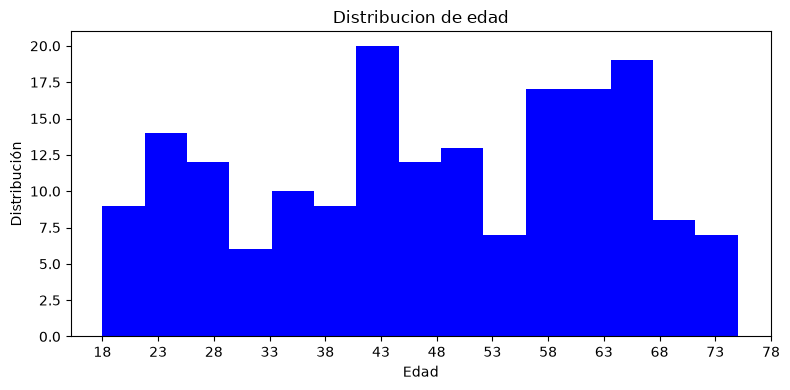

In [44]:
# TODO: crea el histograma de edad
plt.figure(figsize=(8,4))#En pulgadas 8x4
plt.hist(df['edad'], bins=15,color="blue")
plt.xticks(range(18,80,5))
plt.xlabel("Edad")
plt.ylabel("Distribución")
plt.title("Distribucion de edad")
plt.tight_layout()
plt.show()

### Interpretación

**¿Qué información proporciona un histograma que no resulta tan fácil obtener observando directamente las filas del DataFrame?**

Escribe aquí tu respuesta.

### Ejercicio 17 - Abandono

Representa mediante un gráfico de barras el número de clientes que abandonaron y que no abandonaron.

abandono
No    110
Sí     70
Name: count, dtype: int64


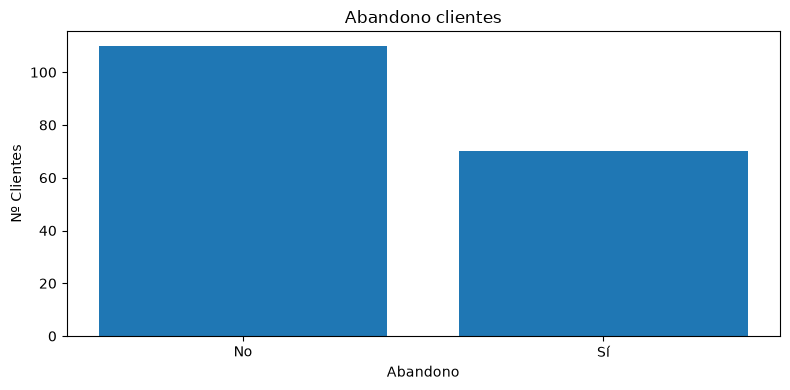

In [45]:
# TODO: crea el gráfico de barras
n_ab = df['abandono'].value_counts()
print(n_ab)

plt.figure(figsize=(8,4))
plt.bar(n_ab.index,n_ab.values)
plt.xlabel("Abandono")
plt.ylabel("Nº Clientes")
plt.title("Abandono clientes")
plt.tight_layout()
plt.show()

### Interpretación

Describe brevemente qué muestra el gráfico.

Escribe aquí tu respuesta.

### Ejercicio 18 - Cuota mensual

Crea un histograma para `cuota_mensual`.

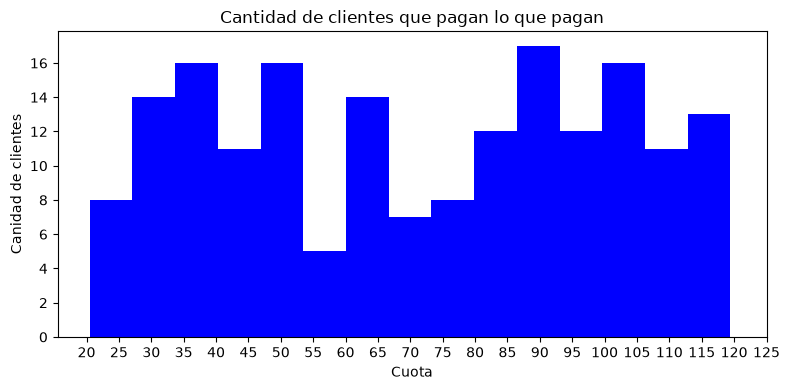

In [46]:
# TODO: crea el histograma de cuota_mensual
plt.figure(figsize=(8,4))#En pulgadas 8x4
plt.hist(df['cuota_mensual'], bins=15,color="blue")
plt.xticks(range(20,130,5))
plt.xlabel("Cuota")
plt.ylabel("Canidad de clientes")
plt.title("Cantidad de clientes que pagan lo que pagan")
plt.tight_layout()
plt.show()

### Interpretación

Analiza visualmente la distribución.

Escribe aquí tu respuesta.

### Ejercicio 19 - Edad y cuota

Crea un diagrama de dispersión utilizando:

\[
x = edad
\]

\[
y = cuota\_mensual
\]

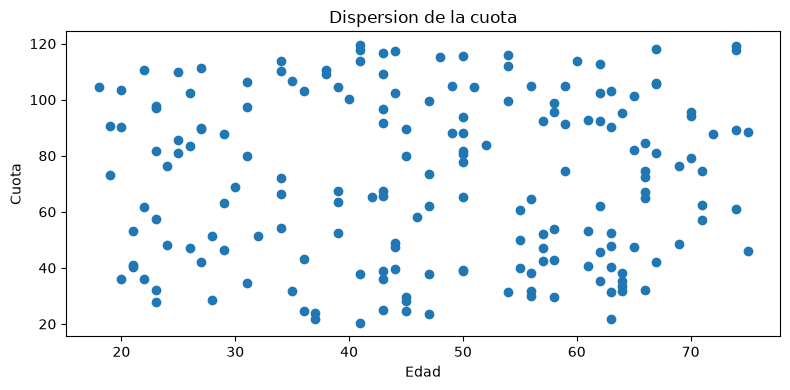

In [47]:
# TODO: crea el diagrama de dispersión
plt.figure(figsize=(8,4))
plt.scatter(df['edad'], df['cuota_mensual'])
plt.xlabel("Edad")
plt.ylabel("Cuota")
plt.title("Dispersion de la cuota")
plt.tight_layout()
plt.show()

### Interpretación

- ¿Qué representa cada punto?
- ¿Observas a simple vista alguna relación clara entre ambas variables?

No es necesario realizar un análisis estadístico.

Escribe aquí tu respuesta.

## Parte 9 - Identificación de $X$ e $y$

La empresa quiere construir en el futuro un modelo que determine si un cliente abandonará.

### Ejercicio 20 - Variable objetivo

Identifica y crea `y`. Después muestra sus cinco primeros valores.

In [48]:
# TODO: crea y
y = df['abandono']

# TODO: muestra sus cinco primeros valores
y.head()

0    No
1    No
2    No
3    No
4    Sí
Name: abandono, dtype: str

### Respuesta

**¿Por qué esta variable corresponde a \(y\)?**

Escribe aquí tu respuesta.

### Ejercicio 21 - Características

Crea `X` utilizando inicialmente estas características:

- `edad`
- `antiguedad`
- `cuota_mensual`
- `consumo_datos`
- `llamadas_soporte`
- `incidencias`
- `tipo_contrato`
- `satisfaccion`

Después comprueba sus dimensiones.

In [49]:
# TODO: crea X
X = df[['edad','antiguedad','cuota_mensual','consumo_datos','llamadas_soporte','incidencias', 'tipo_contrato', 'satisfaccion', 'abandono']]

# TODO: muestra las dimensiones de X
print(X.shape)

(180, 9)


### Respuesta

Si el dataset contiene \(n\) clientes, esperamos:

\[
X.shape = (n,\ ?)
\]

**¿Qué número debe aparecer en `?`? ¿Por qué?**

Escribe aquí tu respuesta.
8, porque son las caracteristicas/ columnas para hacer x

## Parte 10 - Razonamiento de Machine Learning

### Ejercicio 22 - Identificación del problema

Queremos predecir:

`abandono → Sí / No`

Responde razonadamente:

1. ¿Estamos ante aprendizaje supervisado o no supervisado?
Aprendizaje supervisado, porque disponemos de datos históricos de clientes y conocemos el resultado que queremos predecir, es decir, tenemos los resultados con lo que entrenarle.
3. ¿Por qué?
Es aprendizaje supervisado porque tenemos una variable objetivo conocida la x
4. ¿Es clasificación o regresión?
Clasificación porque el objetivo es una clasificacion binaria de si o no
5. ¿Por qué?
Porque no es un número es una clasificacion de 2 tipos
6. ¿Es clasificación binaria o multiclase?
Binaria dado que solo puede ser 2 cosas o 0 (NO) o 1 (SI)
7. ¿Cuáles son las clases?
Sí: el cliente abandonó la compañía.
No: el cliente no abandonó la compañía.

### Respuesta

Escribe aquí tu razonamiento.
Lo he esxrito arriba lo siento

## Parte 11 - Un cambio en el problema

Supongamos ahora que la empresa plantea:

> Queremos predecir cuál será el **consumo de datos del próximo mes** de cada cliente.

### Ejercicio 23

Responde:

1. ¿Cuál sería ahora la variable objetivo?
2. ¿Seguiríamos teniendo exactamente el mismo \(X\)?
3. ¿Sería clasificación o regresión?
4. ¿Seguiría siendo aprendizaje supervisado?
5. Justifica cada respuesta.

### Respuesta

Escribe aquí tu razonamiento.

1. La variable objetivo sería consumo_datos, ya que queremos predecir el consumo de datos del próximo mes.
2. No tendríamos exactamente el mismo X, porque al ser diferente el objetivo habria que ver que columnas analizamos y tal.
3. Sería un problema de regresión, porque el consumo es una variable numérica.
4. Sí, seguiría siendo aprendizaje supervisado, porque dispondríamos de datos históricos en los que conocemos el consumo de datos real y utilizaríamos esos ejemplos para predecir nuevos valores.
5. En resumen, cambiaría la variable objetivo y también el tipo de problema: pasaríamos de una clasificación binaria de abandono a una regresión de consumo_datos.

## Parte 12 - Análisis crítico

### Ejercicio 24 - ¿Utilizarías `cliente_id`?

Los identificadores tienen valores como:

`10001, 10002, 10003, 10004, ...`

¿Utilizarías esta columna como característica para predecir el abandono?

No respondas únicamente «sí» o «no». Razona tu decisión.

### Respuesta

Escribe aquí tu respuesta.

No, no la utilizaría dado que esa columna no tiene ninguna información relevante para nosotros, no nos va a ayudar a predecir nada, sobretodo porque esos datos no tienen nada que ver con el cliente en sí.

### Ejercicio 25 - ¿Estamos preparados para entrenar?

Después del análisis anterior, alguien propone ejecutar directamente:

```python
modelo.fit(X, y)
```

¿Estamos preparados?

Identifica **al menos cuatro cuestiones** que deberíamos estudiar o resolver antes de entrenar el modelo.

No necesitas explicar todavía cómo resolverlas.

### Respuesta

1. Tratar los valores nulos, ya que existen valores que faltan en algunas columnas.
2. Preparar las variables que contengan categorias, especialmente tipo_contrato, ya que contiene texto y muchos modelos necesitan que las categorías se transformen a valores numéricos.
3. Revisar las características de X, eliminando columnas que no aporten información útil como cliente_id.
4. Tener datos extra de prueba, para poder comprobar posteriormente cómo funciona el modelo con datos que no ha visto nunca.
5. Revisar la calidad de los datos, buscando valores incorrectos, posibles valores extremos y otros problemas que puedan afectar al modelo.

## Parte 13 - Conclusiones

### Ejercicio 26 - Informe final

Escribe entre **8 y 12 líneas** resumiendo lo que has descubierto.

Debes incluir como mínimo:

- tamaño del dataset
- principales tipos de variables
- comportamiento de `abandono`
- alguna observación de las estadísticas
- alguna observación de las visualizaciones
- cuáles son \(X\) e \(y\)
- tipo de problema de Machine Learning
- qué pasos deberían realizarse antes de entrenar

### Conclusiones

Escribe aquí tu informe.
El dataset contiene información de 180 clientes y 10 columnas.
Incluye variables numéricas, como edad, antigüedad, cuota mensual... además de variables categóricas como tipo de contrato y abandono.
La variable abandono contiene 110 clientes que no abandonaron y 70 que sí lo hicieron, por lo que aproximadamente el 61,1 % no abandonó y el 38,9 % abandonó.
La edad media de los clientes es de aproximadamente 47,3 años y la cuota mensual media es de 71,19 euros.
También se han detectado algunos valores ausentes en antiguedad y consumo_datos.
Para el problema de abandono, X estará formado por las características de los clientes e y será la variable abandono.
Se trata de un problema de aprendizaje supervisado y de clasificación binaria, ya que queremos predecir Sí o No.
Antes de entrenar un modelo habría que tratar los valores ausentes, preparar las variables categóricas, revisar los datos y separar los conjuntos de entrenamiento y prueba.

---

# Ampliación opcional

Si terminas antes, investiga cómo obtener con pandas:

1. El número exacto de valores ausentes de cada columna.
2. El número de clientes agrupados por `tipo_contrato` y `abandono`.
3. La cuota mensual media de quienes abandonaron y de quienes no.
4. La satisfacción media de ambos grupos.

No utilices algoritmos de Machine Learning.

In [50]:
# AMPLIACIÓN OPCIONAL

# 1. Valores ausentes por columna
print(f"Valores ausentes por columna: \n{df.isna().sum()}")

# 2. Clientes agrupados por tipo_contrato y abandono
print(f"\nClientes agrupados por contrato y abandono:\n {df.groupby(['tipo_contrato', 'abandono']).size()}")

# 3. Cuota mensual media según abandono

print(f"\nCuota mensual media por abandono:\n {df.groupby('abandono')['cuota_mensual'].mean()}")
# 4. Satisfacción media según abandono
print(f"\nSatisfaccion media:\n {df.groupby('abandono')['satisfaccion'].mean()}")

Valores ausentes por columna: 
cliente_id          0
edad                0
antiguedad          2
cuota_mensual       0
consumo_datos       1
llamadas_soporte    0
incidencias         0
tipo_contrato       0
satisfaccion        0
abandono            0
dtype: int64

Clientes agrupados por contrato y abandono:
 tipo_contrato  abandono
Anual          No          36
               Sí          20
Bienal         No          20
               Sí          10
Mensual        No          54
               Sí          40
dtype: int64

Cuota mensual media por abandono:
 abandono
No    71.254727
Sí    71.077143
Name: cuota_mensual, dtype: float64

Satisfaccion media:
 abandono
No    3.345455
Sí    2.500000
Name: satisfaccion, dtype: float64


# Antes de entregar

Comprueba que:

- has completado todas las celdas `TODO`
- has respondido las preguntas en Markdown
- todos los gráficos tienen título y etiquetas
- has reiniciado el entorno y ejecutado el notebook completo desde el principio
- no se producen errores
- no has entrenado ningún modelo

**Nombre recomendado del archivo de entrega:**

`Practica_03_Apellido_Nombre.ipynb`